In [11]:
import matplotlib.pyplot
import pandas
from pathlib import Path

In [38]:
def parse_summary_log(file_path : str) -> pandas.DataFrame:
    columns = ['timestamp_ns', 'core', 'event', 'value', 'enabled', 'running']
    data_frame = pandas.read_csv(file_path, header=None, names=columns)
    data_frame['timestamp_ns'] = pandas.to_datetime(data_frame['timestamp_ns'], unit='ns')
    return data_frame.set_index('timestamp_ns').sort_index().fillna(1.0)

def parse_mutilate_log(file_path : str) -> pandas.DataFrame:
    pass

def plot_event(file_path : str, event : str) -> None:
    data_frame = parse_summary_log(file_path)
    data_frame = data_frame[data_frame['event'] == event]

    normalized = data_frame['value'] * data_frame['running'] / data_frame['enabled']
    per_core_diff = normalized.groupby(data_frame['core']).diff()
    total = per_core_diff.groupby(data_frame.index).sum()

    figure, axis = matplotlib.pyplot.subplots(figsize=(20, 16))
    axis.plot(total)
    axis.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

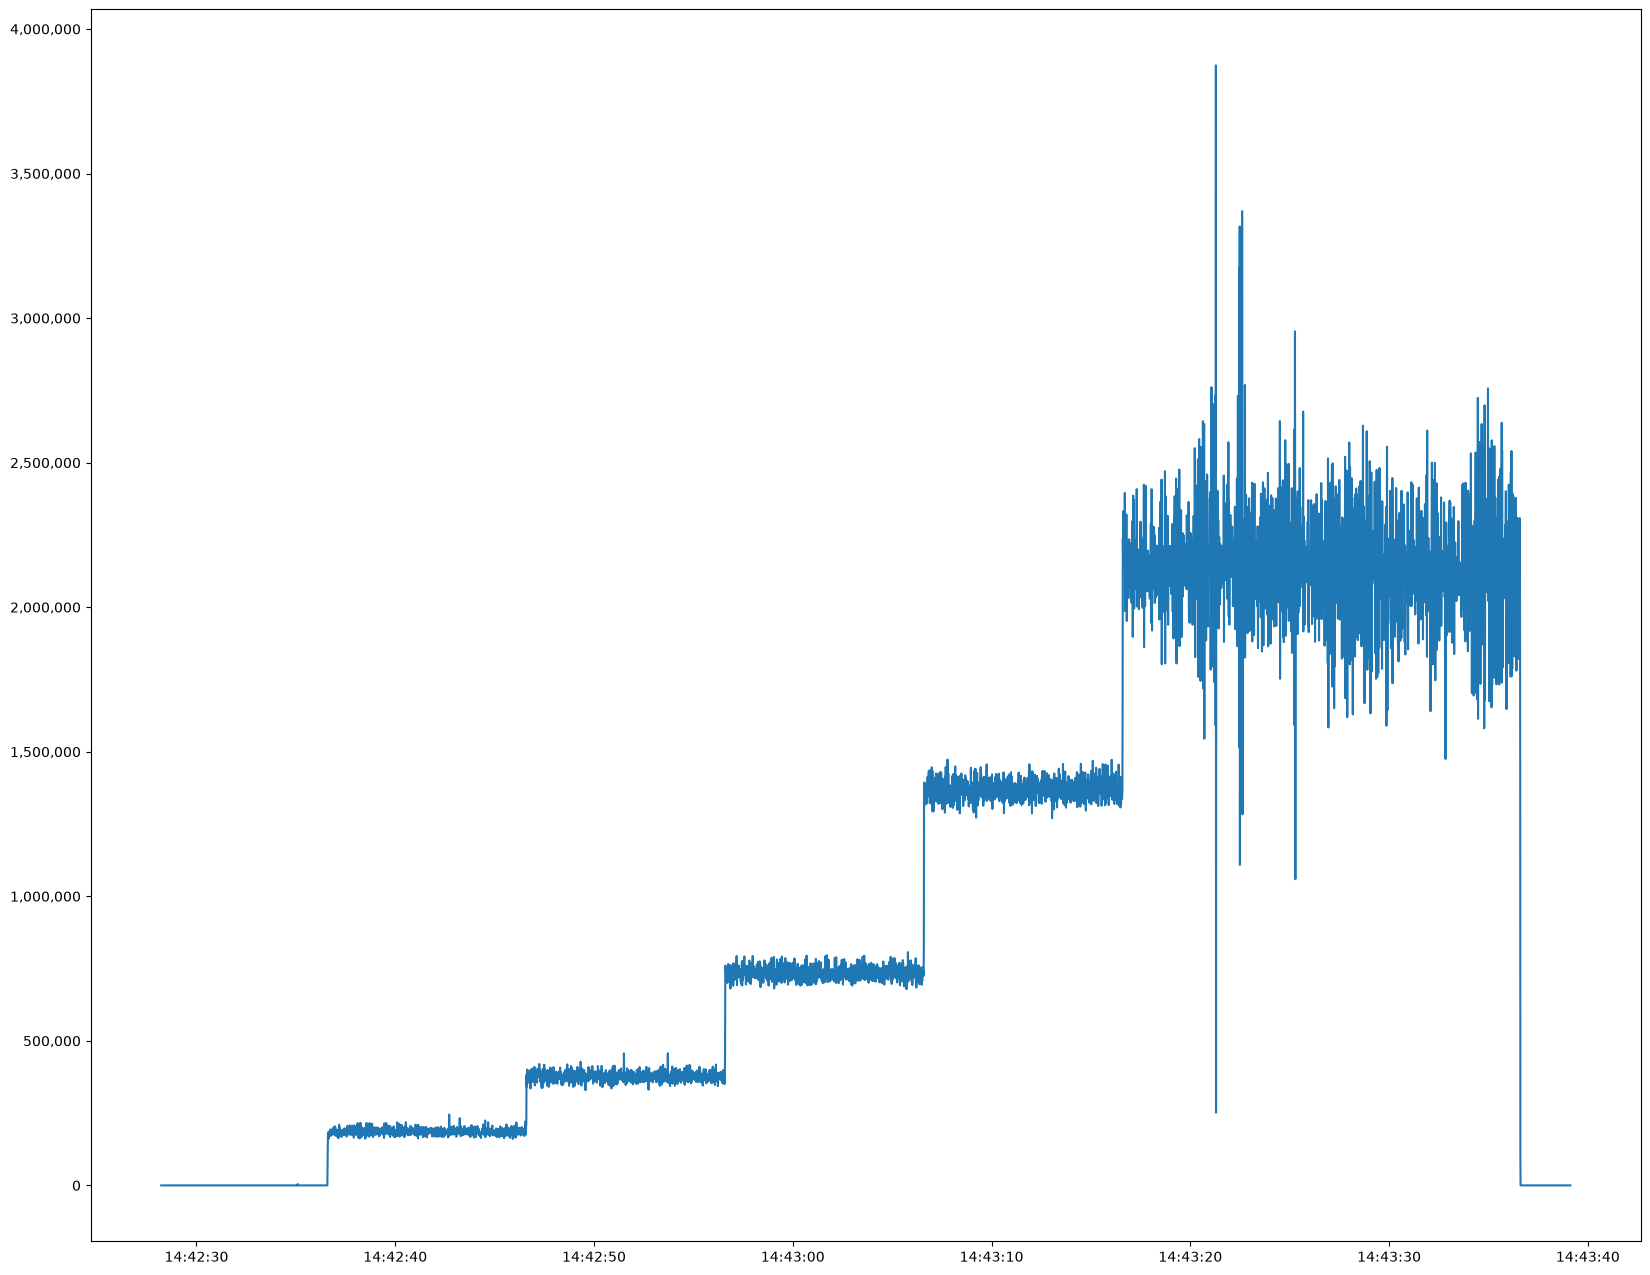

In [39]:
plot_event("results/summary.log", 'rx_bytes')